[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Naive Bayes Accuracy: 0.9775784753363229
Logistic Regression Accuracy: 0.9587443946188341


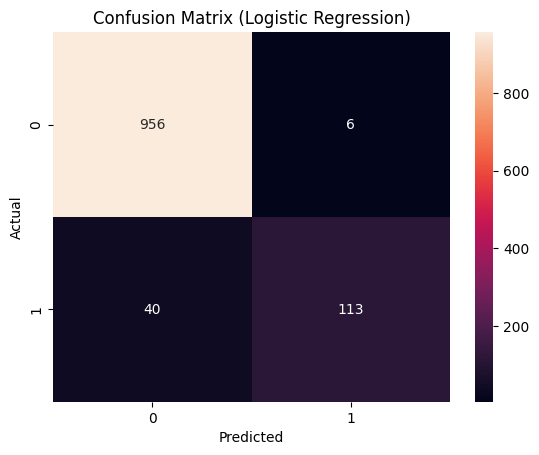

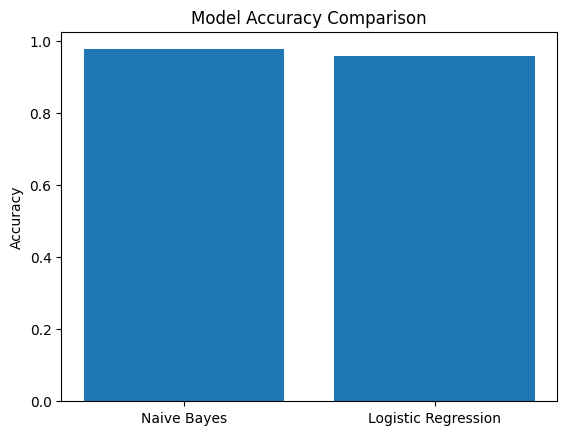

In [2]:
# Install dependencies
!pip install nltk scikit-learn seaborn matplotlib

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset
df = pd.read_csv("/content/spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)

# TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_text'])
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Models
nb = MultinomialNB()
lr = LogisticRegression(max_iter=200)

nb.fit(X_train, y_train)
lr.fit(X_train, y_train)

nb_pred = nb.predict(X_test)
lr_pred = lr.predict(X_test)

# Accuracy
nb_acc = accuracy_score(y_test, nb_pred)
lr_acc = accuracy_score(y_test, lr_pred)

print("Naive Bayes Accuracy:", nb_acc)
print("Logistic Regression Accuracy:", lr_acc)

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy Comparison Graph
models = ['Naive Bayes', 'Logistic Regression']
accuracies = [nb_acc, lr_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()